In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df = pd.read_csv("historical_data.csv", index_col=0, parse_dates=True)

In [15]:
print(df.head())

                  AAPL        AMZN        GOOG        META        MSFT  \
Date                                                                     
2023-03-10  146.379410   90.730003   90.268890  178.264740  242.839050   
2023-03-13  148.321228   92.430000   90.913612  179.645111  248.045776   
2023-03-14  150.410980   94.879997   93.482513  192.674118  254.756851   
2023-03-15  150.805283   96.199997   95.763794  196.378220  259.299286   
2023-03-16  153.624435  100.040001  100.246979  203.508423  269.810455   

                 NVDA        TSLA  
Date                               
2023-03-10  22.945932  173.440002  
2023-03-13  22.946930  174.479996  
2023-03-14  24.043016  183.259995  
2023-03-15  24.207880  180.449997  
2023-03-16  25.519791  184.130005  


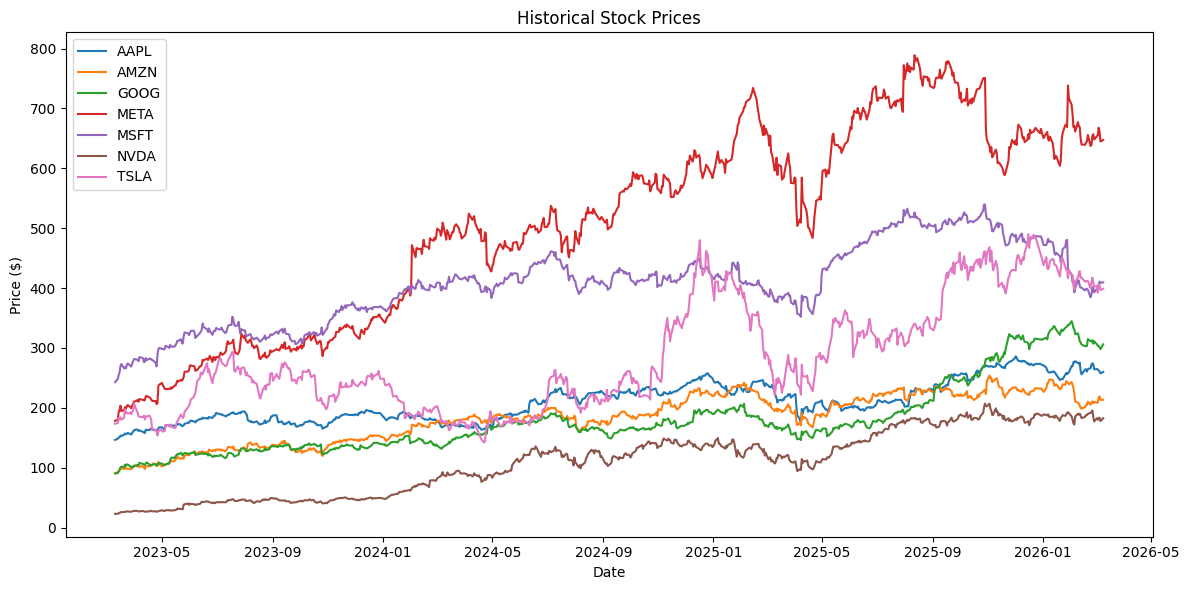

In [16]:
plt.figure(figsize=(12,6))
for ticker in df.columns:
    plt.plot(df.index, df[ticker], label=ticker)


plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
tickers = df.columns
n_tickers = len(tickers)

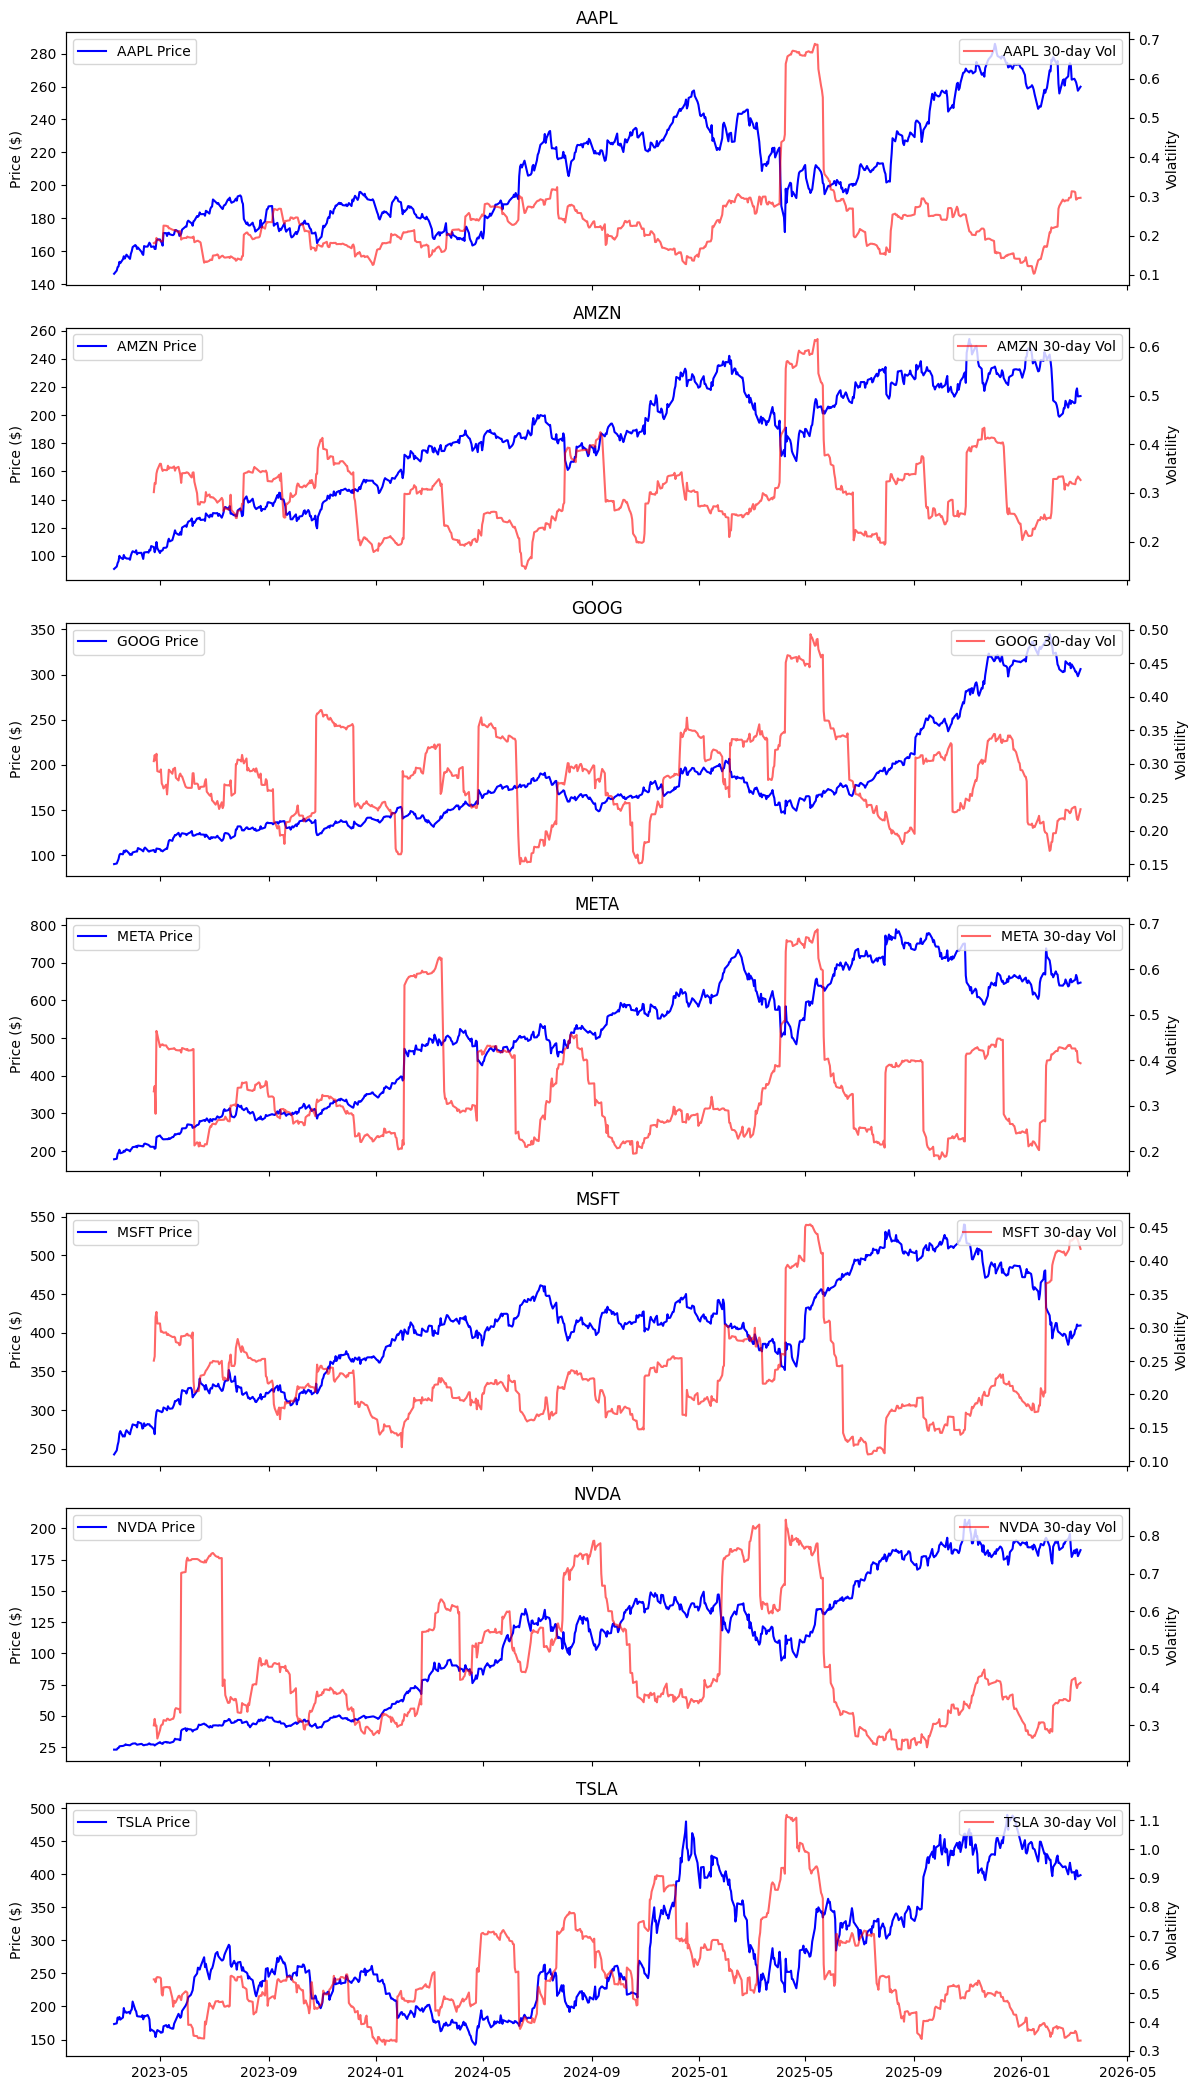

In [ ]:

fig, axes = plt.subplots(n_tickers, 1, figsize=(12, 3*n_tickers), sharex=True)

if n_tickers == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    prices = df[ticker]
    log_returns = np.log(prices / prices.shift(1))
    rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252) #number of trading days in a year

    ax.plot(prices.index, prices, label=f"{ticker} Price", color="blue")
    ax2 = ax.twinx()
    ax2.plot(prices.index, rolling_vol, label=f"{ticker} 30-day Vol", color="red", alpha=0.6)

    ax.set_ylabel("Price ($)")
    ax2.set_ylabel("Volatility")
    ax.set_title(ticker)
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.xlabel("Date")
plt.tight_layout()
plt.show()